# Adding General Relativity
Let's start with our Newtonian flux equation.
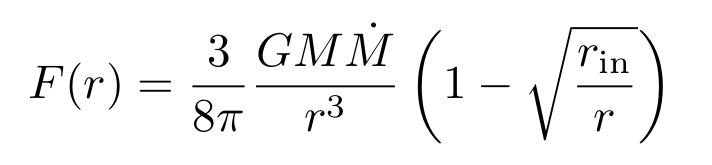
 
We already have a function that can calculate this version of the equation.

In [48]:
import astropy.constants as c
import astropy.units as u
import numpy as np

def F(r, M, Mdot, r_in):
    flux = 3. * c.G * M * Mdot / (8. * np.pi * r**3) * (1. - np.sqrt(r_in / r))    # Calculate the flux
    flux[flux<0.] = 0.
    return flux.to(u.Unit("erg/(cm2 s)"))

Now, we want to replace it with this equation:

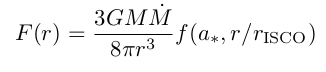

The only difference is that the $(1-\sqrt\frac{r_{in}}{r})$ term has been replaced with this function *f*, which describes the radial dependence due to the effects of general relativity.

In [50]:

import matplotlib.pyplot as plt

def gr(m):
    grav_radius = ((c.G * m) / (c.c**2))
    return grav_radius.to(u.cm)

def f_function(a, r, M):
    qcor, tcor = grcor(a, r/gr(M))
    return tcor**4

Now we should be able to plot this f function and see what its behavior is like compared with the Newtonian piece we had before. Let's do that.

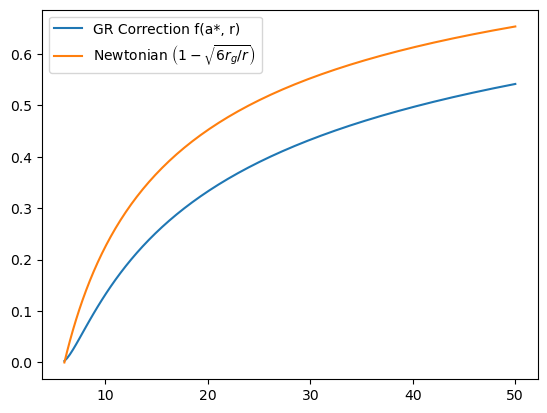

In [52]:
# Choose values for the mass and black hole spin, "a_bh"
a_bh = 0.1 # Black hole spin is unitless
mass = 6.62*u.solMass

# Generate some radii in log space (this makes sure the data points are closer together closer to the black hole)
r = np.logspace(np.log10(6*gr(mass).value), np.log10(50*gr(mass).value))*u.cm

# Calculate the values of the f function at the radii we've picked.
f_values = f_function(a_bh, r, mass)

# Calculate the equivalent piece of the Newtonian equation
Newtonian_values = 1 - np.sqrt(6*gr(mass) / r)

# Plot the two functions
plt.plot(r/gr(mass), f_values, label='GR Correction f(a*, r)')
plt.plot(r/gr(mass), Newtonian_values, label=r'Newtonian $\left(1-\sqrt{6r_g/r}\right)$')
plt.legend()
plt.show()

Great! Now, your task is to use this `f_function` to get the actual **flux** from this GR calculation. Remember, the only difference between the GR flux function and the Newtonian flux function (which you've already written) should be the term in parentheses with the 1-sqrt(r_in/r). This needs to be replaced with our `f_function` to get the GR flux as a function of radius.

I've done the first step for you below: we've defined a new function ``

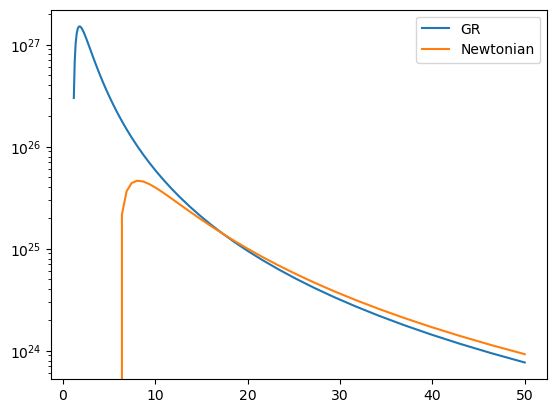

In [62]:

import matplotlib.pyplot as plt

def gr(m):
    grav_radius = ((c.G * m) / (c.c**2))
    return grav_radius.to(u.cm)

def F_gr(r, M, Mdot):
    flux = (3 / (8 * np.pi)) * (c.G * M * Mdot) / r**3 * f_values
    return flux.to(u.Unit("erg/(cm2 s)"))

# Set the mass equal to what we used in the simulation
mass = 6.62*u.solMass

# We've measured the approximate accretion rate of this system using the fit of the temperature, so let's plug it in!
accr_rate = 0.000025*u.solMass/u.yr

# Create an array of r points. I've done this in log space so the plot looks better.
# This is from 1.2 gravitational radii to 50 gravitational radii.
r = np.logspace(np.log10(1.2*gr(mass).value), np.log10(50*gr(mass).value))*u.cm

# plot both lines
plt.plot(r/gr(mass), F_gr(r, mass, accr_rate), label='GR')
plt.plot(r/gr(mass), F(r, mass, accr_rate, 6*gr(mass)), label='Newtonian')
plt.yscale('log')
plt.legend()
plt.show()

In [46]:

"""
Plot accretion disk variables
"""

# standard python modules
import argparse
import numpy as np
import matplotlib.pyplot as plt

def grcor(abh,r):
  """
  Pythonized version of dispar.f routine used with kerrtrans
  """

  if(abh < 0.):
    signa=-1.
  else:
    signa=1.0

  abh2 = abh * abh
  r1 = 1.0/r
  r12 = np.sqrt(r1)
  r2 = r1*r1
  a2r2 = abh2*r2
  a4r4 = a2r2*a2r2
  a2r3 = abh2*r2*r1
  ar32 = np.sqrt(a2r3)

  A = 1 + a2r2 + 2.*a2r3
  B = 1 + ar32
  C = 1 - 3.*r1 + 2.*ar32
  D = 1 - 2.*r1 + a2r2
  E = 1 + 4.*a2r2 - 4.*a2r3 + 3*a4r4

  # gravity correction  (see Page & Thorne,'73, eq.35) 
  qcor = (1. - 4.*ar32 + 3.*a2r2)/C

  # Minimum radius for last stable circular orbit per unit mass, x0
  z1 = 1.0+(1.0-abh2)**(1.0/3.0)*((1.0+abh)**(1.0/3.0)+(1.0-abh)**(1.0/3.0))
  z2 = np.sqrt(3.0*abh2+z1*z1)
  r0 = 3.0+z2-signa*np.sqrt((3.0-z1)*(3.0+z1+2.0*z2))
  x0 = np.sqrt(r0)

  # roots of x^3 - 3x + 2a = 0
  ca3 = 1.0/3.0 * np.arccos(abh)
  x1 =  2.*np.cos(ca3-np.pi/3.)
  x2 =  2.*np.cos(ca3+np.pi/3.)
  x3 = -2.*np.cos(ca3)

  # FB = '[]' term in eq. (35) of Page&Thorne '73
  x = np.sqrt(r)
  c1 = 3*(x1-abh)*(x1-abh)/(x1*(x1-x2)*(x1-x3))
  c2 = 3*(x2-abh)*(x2-abh)/(x2*(x2-x1)*(x2-x3))
  c3 = 3*(x3-abh)*(x3-abh)/(x3*(x3-x1)*(x3-x2))
  al0 = 1.5*abh * np.log(x/x0)
  al1 = np.log((x-x1)/(x0-x1))
  al2 = np.log((x-x2)/(x0-x2))
  al3 = np.log((x-x3)/(x0-x3))
  fb = (x-x0 - al0 - c1*al1 - c2*al2 - c3*al3)
  Q = fb*(1.0+ar32)*r12/np.sqrt(1.0-3.0*r1+2.0*ar32)

  # temperature correction
  tcor = (Q/B/np.sqrt(C))**0.25

  inds0 = np.where(r < r0)

  #nx = r.shape[0]
  #ny = r.shape[1]

  tcor[inds0] = 0.
  qcor[inds0] = 0.

  return qcor,tcor


def DiskFlux(mass,mdot,radius,abh):
    """
    Returns the flux as a function of radius, mass, accretion rate but without
    relativistic and no-torque correction, which is provided by grcor
    """
    G = 6.67430e-8
    msun = 1.99e33
    kapes = 0.34
    c = 2.99792458e10

    # Minimum radius for last stable circular orbit per unit mass, X0
    abh2 = abh*abh
    signa = 1.0
    z1 = 1.0+(1.0-abh2)**(1.0/3.0)*((1.0+abh)**(1.0/3.0)+(1.0-abh)**(1.0/3.0))
    z2 = np.sqrt(3.0*abh2+z1*z1)
    r0 = 3.0+z2-signa*np.sqrt((3.0-z1)*(3.0+z1+2.0*z2))

    eta = 1.0 - (r0**2 - 2.0*r0 + abh*r0**0.5)/r0/(r0**2 - 3.0*r0 + 2.0*abh*r0**0.5)**0.5

def rms(abh):

    abh2 = abh*abh
    if (abh < 0):
        signa = -1.
    else:
        signa = 1.
    z1 = 1.0+(1.0-abh2)**(1.0/3.0)*((1.0+abh)**(1.0/3.0)+(1.0-abh)**(1.0/3.0))
    z2 = np.sqrt(3.0*abh2+z1*z1)
    r0 = 3.0+z2-signa*np.sqrt((3.0-z1)*(3.0+z1+2.0*z2))
    return r0

def plot_rr():
    """
    plot the R_R factor
    """
    nr = 1000
    rmax = 1000.
    rmin = 1.
    # plot a= 0 first
    abh = 0.
    r = np.logspace(np.log10(rmin),np.log10(rmax),nr)
    # Krolik's R_R is tcor**4
    qcor, tcor = grcor(abh,r)
    plt.plot(r,tcor**4,'k', label='$a_*=0$')

    # plot a = 0.99
    abh = 0.99
    qcor, tcor = grcor(abh,r)
    plt.plot(r,tcor**4,'k',linestyle='dotted', label='$a_*=0.99$')

    # plot newtonian
    fnewt = 1.-np.sqrt(6./r)
    fnewt[(fnewt < 0.)] = 0.
    plt.plot(r,fnewt,'k',linestyle='dashed', label='Newtonian')

    plt.ylabel(r'$R_R$')
    plt.xlabel(r'$r/r_g$')
    plt.xscale('log')
#    plt.savefig("flux_cor.png")
    plt.legend()
    plt.show()

# Main function
def main(**kwargs):

    plot = kwargs.pop('plot')
    if (plot is None):
        # generate all plots
        plot_rr()


# Execute main function
if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--plot',
        default=None,
        help='specific plot')

    args = parser.parse_args()
    main(**vars(args))


usage: ipykernel_launcher.py [-h] [--plot PLOT]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/sagnik/.local/share/jupyter/runtime/kernel-7360b2a0-7b0d-499d-a340-20db7a13dd6f.json


SystemExit: 2